# Simulation of Solidification and Cooling Behaviour in Aluminium Alloy
**Author:** Dhrubajyoti Bhattacharjee
**Type:** Independent Computational Metallurgy Study
**Year:** 2026

## Abstract:
This project presents a numerical simulation of solidification and cooling behaviour of an aluminium alloy slab using Python. The study evaluates cooling curves, temperature distribution, solid fraction evolution, and key thermophysical parameters including thermal diffusivity, fourier number, and solidification front velocity.

## 1. Introduction
Solidification is a critical stage in metal casting processes, as it directly influences microstructure and final mechanical properties. During cooling from the molten state, heat is extracted from the material, leading to temperature reduction and phase transformation.
This notebook presents a non-dimensional numerical simulation of the cooling and solidification behaviour of an aluminium slab using Python.

## 2. Objective
The objective of this study is to:

(a).Simulate transient cooling behaviour of molten aluminium.
(b).Estimate solidification time.
(c).Calculate cooling rate and total heat removal.
(d).Evaluate thermal diffusivity and thermal gradient.
(e).Determine solidification front velocity.

## 3. Problem Statement

To simulate the transient cooling and solidification behaviour of 2 cm thick aluminium alloy slab and determine:
(a).Cooling curve at center.
(b).Final temperature distribution.
(c).Solid fraction distribution.
(d).Mass of slab.
(e).Sensible heat removed.
(f).Latent heat released.
(g).Total heat removed.
(h).Thermal diffusivity.
(i).Fourier number.
(j).Thermal grradient.
(k).Solidification front velocity.


## 4. Materials Properties and Input Parameters:

(a).Density(ρ)=2700 kg/m^3
(b).Thermal Conductivity(k)=150 W/mK
(c).Specific Heat Capacity(Cp)=900 J/kgK
(d).Latent Heat of Fusion(L)=397,000 J/kg
(e).Melting Temperature(Tm)=660°C
(f).Initial Temperature(Ti)=750°C
(g).Ambient Temperature(Ta)=25°C
(h).Slab Thickness=0.02m

Thermal Diffusivity (alpha): 6.17283950617284e-05 m2/s
Estimated Solidification Time: 0.8449920000000001 seconds


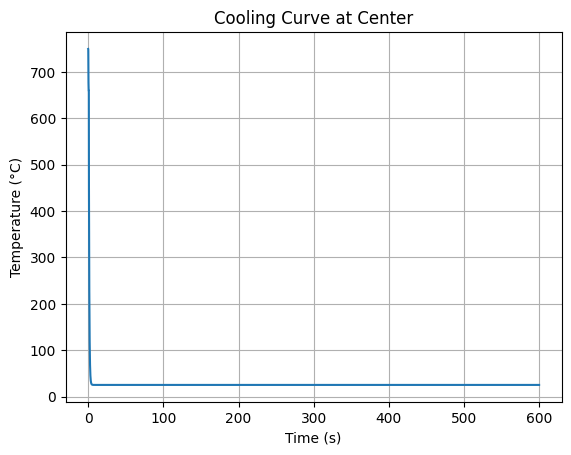

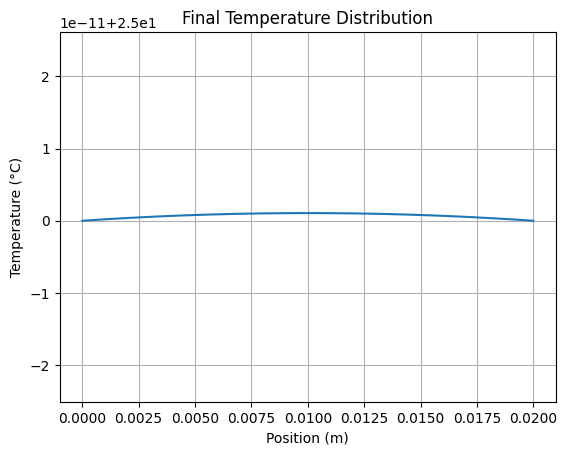

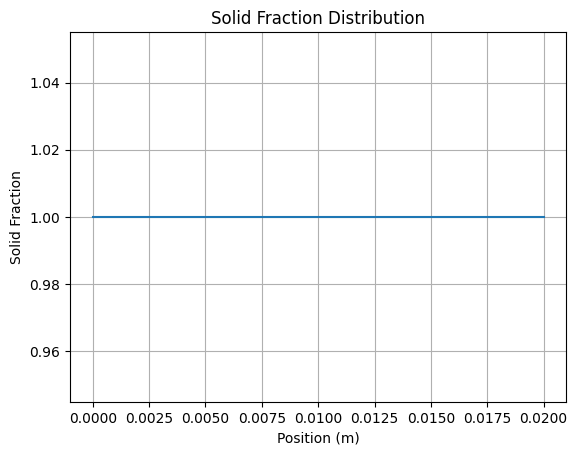

===== Numerical Results =====

Cooling Rate: 0.2984 C/s

Mass of Slab:  54.00 kg

Sensible Heat Removed: 4374000.00 J
Latent Heat Removed: 21438000.00 J
Total Heat removed: 25812000.00 J

Thermal Diffusivity: 7.407407e-05m^2/s

Fourier Number: 55.56

Thermal Gradient: 36250.00 K/m

Solidification Front Velocity: 8.230453e-06 m/s

===== END OF SIMULATION =====


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# MATERIAL PROPERTIES (Aluminum Alloy)
# -----------------------------
rho = 2700                 # kg/m3
k = 150                    # W/m.K
cp = 900                   # J/kg.K
L_latent = 397000          # J/kg
T_melt = 660               # °C

alpha = k / (rho * cp)     # Thermal diffusivity

# -----------------------------
# GEOMETRY
# -----------------------------
length = 0.02              # 2 cm slab
Nx = 50
dx = length / Nx

# -----------------------------
# TIME PARAMETERS
# -----------------------------
dt = 0.4 * dx**2 / alpha   # Stability condition
total_time = 600           # seconds
Nt = int(total_time / dt)

# -----------------------------
# INITIAL CONDITIONS
# -----------------------------
T_initial = 750            # °C
T_ambient = 25             # °C

T = np.ones(Nx) * T_initial
T_new = T.copy()

# Track cooling curve at center
center_index = Nx // 2
cooling_curve = []
time_array = []

# Track solidification
solid_fraction = np.zeros(Nx)
solidification_time = None

# -----------------------------
# SIMULATION LOOP
# -----------------------------
for n in range(Nt):

    for i in range(1, Nx-1):
        T_new[i] = T[i] + alpha * dt / dx**2 * (T[i+1] - 2*T[i] + T[i-1])

    # Boundary conditions (cooling at surfaces)
    T_new[0] = T_ambient
    T_new[-1] = T_ambient

    # ---- Latent Heat Treatment ----
    for i in range(Nx):
        if T_new[i] <= T_melt and solid_fraction[i] < 1:
            # Energy removal goes into phase change
            energy_removed = rho * cp * (T_melt - T_new[i])
            fraction = energy_removed / (rho * L_latent)
            solid_fraction[i] += fraction

            if solid_fraction[i] >= 1:
                solid_fraction[i] = 1
            T_new[i] = T_melt

    # Update temperature
    T[:] = T_new[:]

    cooling_curve.append(T[center_index])
    time_array.append(n * dt)

    # Check full solidification
    if np.all(solid_fraction >= 1) and solidification_time is None:
        solidification_time = n * dt

# -----------------------------
# RESULTS
# -----------------------------

print("Thermal Diffusivity (alpha):", alpha, "m2/s")
print("Estimated Solidification Time:", solidification_time, "seconds")

# 1️⃣ Cooling Curve
plt.figure()
plt.plot(time_array, cooling_curve)
plt.xlabel("Time (s)")
plt.ylabel("Temperature (°C)")
plt.title("Cooling Curve at Center")
plt.grid()
plt.show()

# 2️⃣ Final Temperature Distribution
plt.figure()
x = np.linspace(0, length, Nx)
plt.plot(x, T)
plt.xlabel("Position (m)")
plt.ylabel("Temperature (°C)")
plt.title("Final Temperature Distribution")
plt.grid()
plt.show()

# 3️⃣ Solid Fraction Distribution
plt.figure()
plt.plot(x, solid_fraction)
plt.xlabel("Position (m)")
plt.ylabel("Solid Fraction")
plt.title("Solid Fraction Distribution")
plt.grid()
plt.show()


rho=2700#Density(kg/m^3)
k=180#Thermal Conductivity(W/mk)
cp=900#Specific heat(J/kgK)
l=397000#Latent Heat(J/Kg)
Tm=660#Melting Temp(degree Celcius)
Ti=750#Initial Temp(degree Celcius)
Ta=25#Ambient Temperature(degree celcius)
thickness=0.02#2cm slab(m)
h=20#heat transfer coefficient (W/m^2K) (natural convection assumption)

#Assume 1 m^2 surface area slab
area=1
volume=area*thickness
mass=rho*volume

#
#1. Cooling Rate
#

delta_T=Ti-Ta
cooling_rate= (h*delta_T)/(rho * cp * thickness)

#
#2. Total Heat Removed
#

Q_sensible=mass*cp*(Ti-Tm)
Q_latent=mass*l
Q_total=Q_sensible+Q_latent

#
#3. Thermal Diffusivity
#

alpha=k/(rho*cp)

#Assume approximate solidification time (seconds)
solidification_time=300

#
#4. Fourier Number
#

Fo=(alpha * solidification_time)/(thickness**2)

#
#5. Thermal Gradient
#

thermal_gradient=(Ti-Ta)/thickness

#
#6.Solidification Front Velocity
#

solidification_velocity=cooling_rate/thermal_gradient

#
#Print Results
#

print("===== Numerical Results =====\n")

print(f"Cooling Rate: {cooling_rate:.4f} C/s")

print(f"\nMass of Slab: {mass: .2f} kg")

print(f"\nSensible Heat Removed: {Q_sensible:.2f} J")

print(f"Latent Heat Removed: {Q_latent:.2f} J")

print(f"Total Heat removed: {Q_total:.2f} J")

print(f"\nThermal Diffusivity: {alpha:.6e}m^2/s")

print(f"\nFourier Number: {Fo:.2f}")

print(f"\nThermal Gradient: {thermal_gradient:.2f} K/m")

print(f"\nSolidification Front Velocity: {solidification_velocity:.6e} m/s")

print("\n===== END OF SIMULATION =====")


## 5. Results:

###Cooling Curve
The center temperature decreases exponentially due to heat diffusion towards the cooled boundaries.

###Final Temperature Distribution
The slab reaches near-uniform temperature after sufficient time, indicating strong thermal diffusion (high Fourier number).

###Solid Fraction Distribution
The solid fraction becomes nearly 1 accross the slab, indicating complete solidification.

## 6. Thermal Analysis:

Thermal Diffusivity:

α=k/(ρCp)

Fourier Number:

Fo=αt/L^2

Thermal Gradient:

G=ΔT/thickness

Solidification Front Velocity:

V=Cooling Rate/Thermal Gradient.


## 7. Conclusion:

The simulation succesfully models the transient cooling and solidification behaviour of aluminium alloy.

(i).Rapid heat diffusion confirmed by high Fourier number.
(ii).Latent heat dominates total energy removal.
(iii).Solidification front velocity is in micrometer/second range.
(iv).Complete solidification achieved under given boundary conditions.

The model demonstrates the application of numerical heat transfer methods in metallurgical process simulation.